# Polymarket Deep Insights

## Resumen del estudio

Este cuaderno presenta un análisis aplicado de mercados de Polymarket con una lógica de investigación: primero se valida la calidad y cobertura de los datos, después se estudian relaciones entre precio, actividad de trading, señales externas y referencias de Chainlink, y finalmente se sintetizan hallazgos útiles para decisión.

El objetivo no es forzar un modelo complejo, sino entender qué patrones son defendibles con el snapshot disponible. Por eso, cada bloque prioriza interpretabilidad y control de sesgos de cobertura temporal.

## Alcance y fuentes

La base del análisis combina datos ya integrados del ecosistema (precio, operaciones, componentes on-chain y referencias de Chainlink) con señales externas agregadas. Cuando la granularidad de señales por hora exacta no es suficiente, se usan ventanas temporales para evitar conclusiones artificiales.

## Criterio metodológico

La lectura de resultados sigue un principio conservador: si una relación no tiene cobertura suficiente o no supera un baseline simple, se reporta como preliminar. Esto permite separar hallazgos robustos de hipótesis para la siguiente iteración de datos.

## 1. Preparación del entorno de investigación

Este primer bloque fija librerías, configuración visual y rutas de datos. La meta es garantizar reproducibilidad y dejar explícito que todo el análisis parte de artefactos locales ya generados, sin relanzar extracciones largas.

La lectura esperada al final de este bloque es simple: confirmar que las carpetas de ontología y curado existen y que el entorno está listo para análisis consistente.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 220)
sns.set_theme(style='whitegrid')

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
DATA_ONTOLOGY = ROOT / 'data' / 'datasets' / 'ontology'
DATA_CURATED = ROOT / 'data' / 'datasets' / 'curated'

print('ROOT:', ROOT)
print('Ontology dir exists:', DATA_ONTOLOGY.exists())
print('Curated dir exists:', DATA_CURATED.exists())

ROOT: /home/artur/GSR/gsr-market-intelligence/backend
Ontology dir exists: True
Curated dir exists: True


El entorno quedó correctamente inicializado con `ROOT=/home/artur/GSR/gsr-market-intelligence/backend`, y ambas rutas críticas existen (`ontology` y `curated`). Esto confirma que el cuaderno está leyendo artefactos locales ya construidos y que la ejecución es reproducible sobre este snapshot, sin depender de peticiones en vivo a APIs externas.

### 1.2 Verificación de calidad declarada en manifests

Antes de analizar relaciones, se comprueba el estado de calidad reportado por los manifests de ontología y dataset curado. Esta validación es crítica para no interpretar como señal lo que en realidad son vacíos de ingestión.

La salida de este bloque se interpreta como semáforo de confiabilidad inicial y define el tono (robusto o prudente) de las conclusiones posteriores.

In [2]:
def read_manifest(path: Path) -> dict:
    if not path.exists():
        return {}
    return json.loads(path.read_text(encoding='utf-8'))

manifest_ontology = read_manifest(DATA_ONTOLOGY / 'manifest.json')
manifest_curated = read_manifest(DATA_CURATED / 'manifest.json')

if manifest_ontology:
    print('Ontology quality_passed:', manifest_ontology.get('quality_passed'))
    print('Ontology quality_failures:', manifest_ontology.get('quality_failures', []))
    print('Ontology row_counts:', manifest_ontology.get('row_counts', {}))
else:
    print('No ontology manifest found. Run extraction first.')

if manifest_curated:
    print('Curated row_counts:', manifest_curated.get('row_counts', {}))
else:
    print('No curated manifest found. Run scripts/build_curated_analysis_dataset.py first.')

Ontology quality_passed: False
Ontology quality_failures: ['markets_with_price_series=17 < 40', 'markets_with_wallet_activity=0 < 8', 'markets with >=5 trades=38 < 50']
Ontology row_counts: {'markets': 70, 'resolutions': 200, 'market_resolution_links': 25, 'price_series': 1037, 'orderbook_snapshots': 70, 'trades': 7408, 'holders': 139, 'wallet_activity': 0, 'chainlink_latest': 16, 'chainlink_series': 976, 'contract_events': 100, 'external_signals': 265}
Curated row_counts: {'market_hourly_features': 1037, 'market_summary': 17}


En este corte, la ontología declara `quality_passed=False` por tres motivos puntuales: mercados con `price_series` por debajo de umbral (`17 < 40`), cobertura nula en `wallet_activity` (`0 < 8`) y mercados con al menos 5 trades por debajo del mínimo (`38 < 50`). Aun así, sí hay base analítica en varios frentes (`price_series=1037`, `trades=7408`, `chainlink_series=976`, `external_signals=265`) y el dataset curado consolida `1037` filas en `17` mercados. La lectura correcta es: hay evidencia suficiente para análisis exploratorio robusto en el subconjunto cubierto, pero no para extrapolar con la misma fuerza a todos los mercados.

## 2. Construcción del panel analítico y control de cobertura

En este bloque se carga el dataset curado por hora, se crean variables operativas y se verifica rango temporal efectivo. Es la transición entre extracción técnica y análisis estadístico.

Tras ejecutar, las métricas de cobertura deben leerse como condición de validez del resto del cuaderno: delimitan qué preguntas pueden responderse con rigor en este corte.

In [3]:
required_curated = DATA_CURATED / 'market_hourly_features.parquet'
if required_curated.exists():
    features = pd.read_parquet(required_curated)
else:
    raise FileNotFoundError(
        f'Missing {required_curated}. Build curated dataset before running this notebook.'
    )

features['timestamp_hour'] = pd.to_datetime(features['timestamp_hour'], utc=True, errors='coerce')
features['signals_count'] = pd.to_numeric(features.get('signals_count'), errors='coerce').fillna(0)
features['signals_last_24h'] = pd.to_numeric(features.get('signals_last_24h'), errors='coerce').fillna(0)
features['signal_feature'] = (
    features['signals_last_24h'] if 'signals_last_24h' in features.columns else features['signals_count']
)
features['trades_count'] = pd.to_numeric(features.get('trades_count'), errors='coerce').fillna(0)
features['abs_return_1h'] = pd.to_numeric(features.get('price_return_1'), errors='coerce').abs()

print('Rows:', len(features))
print('Markets:', features['market_id'].nunique())
print('Time range:', features['timestamp_hour'].min(), '->', features['timestamp_hour'].max())

coverage = pd.DataFrame({
    'metric': ['rows', 'markets', 'rows_with_chainlink', 'rows_with_signal_feature', 'rows_with_trades'],
    'value': [
        len(features),
        features['market_id'].nunique(),
        int(features['chainlink_price_usd_hour'].notna().sum()) if 'chainlink_price_usd_hour' in features.columns else 0,
        int((features['signal_feature'] > 0).sum()),
        int((features['trades_count'] > 0).sum()),
    ],
})
coverage

Rows: 1037
Markets: 17
Time range: 2026-06-19 11:00:00+00:00 -> 2026-06-19 12:00:00+00:00


,metric,value
0,rows,1037
1,markets,17
2,rows_with_chainlink,976
3,rows_with_signal_feature,1037
4,rows_with_trades,743


El panel efectivo queda en `1037` filas y `17` mercados, pero concentrado en una ventana temporal muy corta (`2026-06-19 11:00` a `12:00` UTC). La cobertura por variable es desigual: `976` filas con referencia de Chainlink, `743` con actividad de trades y `1037` con `signal_feature` positivo (por construcción de ventana temporal). Esto habilita contraste entre señal agregada, trading y gap con Chainlink dentro del snapshot, pero limita inferencia temporal fuerte por la poca profundidad histórica del rango.

## 3. Estructura de mercado por cohortes y actividad

Con la base ya cargada, este segmento caracteriza perfiles de mercado mediante volatilidad intrahoraria, actividad de señales en ventana y volumen operativo. El propósito es construir contexto descriptivo antes de pasar a inferencia temporal.

La interpretación posterior permite identificar si el comportamiento está concentrado en un único tipo de mercado o distribuido de forma más homogénea.

,markets,rows,avg_abs_return_1h,avg_signals_window,avg_trades
cohort,,,,,
A_active_liquid,17,1037,0.001267,3.882353,3.456123


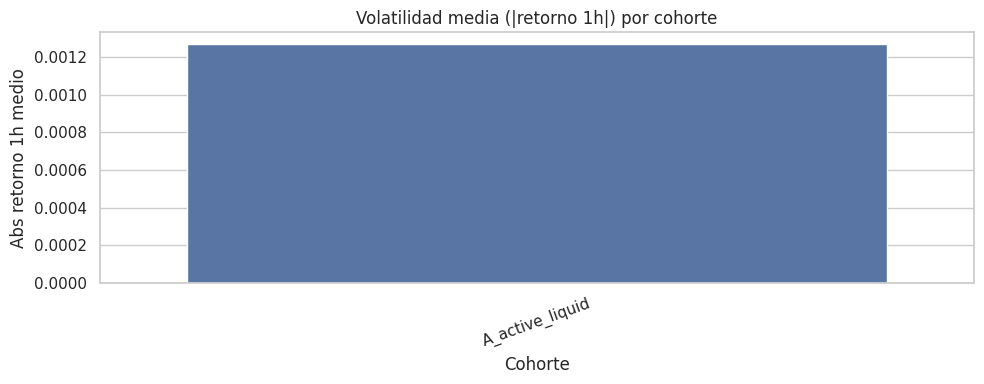

In [4]:
cohort_col = 'cohort' if 'cohort' in features.columns else None
if cohort_col:
    cohort_stats = (
        features.groupby(cohort_col, dropna=False)
        .agg(
            markets=('market_id', 'nunique'),
            rows=('market_id', 'size'),
            avg_abs_return_1h=('abs_return_1h', 'mean'),
            avg_signals_window=('signal_feature', 'mean'),
            avg_trades=('trades_count', 'mean'),
        )
        .sort_values('avg_abs_return_1h', ascending=False)
    )
    display(cohort_stats)

    plt.figure(figsize=(10, 4))
    sns.barplot(x=cohort_stats.index.astype(str), y=cohort_stats['avg_abs_return_1h'])
    plt.title('Volatilidad media (|retorno 1h|) por cohorte')
    plt.xlabel('Cohorte')
    plt.ylabel('Abs retorno 1h medio')
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()
else:
    print('No cohort column found in curated dataset.')

La muestra está totalmente concentrada en una sola cohorte (`A_active_liquid`), que reúne los `17` mercados y las `1037` filas del panel. Sus medias son: `|retorno 1h|=0.001267`, `señal ventana=3.882353` y `trades=3.456123`. Como no hay otras cohortes comparables en este snapshot, la lectura no es “diferencias entre tipos de mercado”, sino una foto interna de este único perfil de mercado activo y líquido.

### 3.1 Relación temporal señal-retorno (lags)

Este bloque evalúa si la señal externa agregada anticipa variaciones de volatilidad en distintos retrasos horarios. Es una prueba exploratoria de estructura temporal, con umbral mínimo de cobertura para evitar inferencias espurias.

Después de ejecutar, la lectura clave es la estabilidad de la correlación según lag y tamaño muestral efectivo en cada punto.

Rows con señal_feature > 0: 1037


,lag_hours,corr_signals_vs_abs_return,n
0,0,-0.005613,1020
1,1,-0.005613,1020
2,3,-0.006101,986
3,6,-0.007787,935
4,24,-0.028321,629


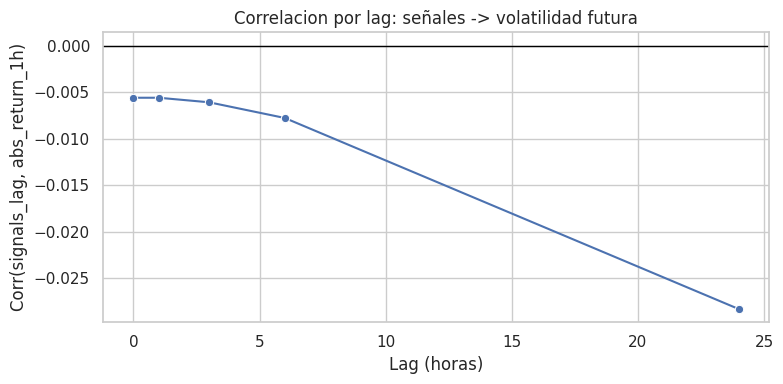

In [5]:
signals_positive = int((features['signal_feature'] > 0).sum())
print('Rows con señal_feature > 0:', signals_positive)

if signals_positive < 30:
    print('Cobertura de señales insuficiente para análisis de lags fiable en este snapshot.')
    lag_corr = pd.DataFrame(
        {
            'lag_hours': [0, 1, 3, 6, 24],
            'corr_signals_vs_abs_return': [np.nan] * 5,
            'n': [signals_positive] * 5,
        }
    )
    display(lag_corr)
else:
    lags = [0, 1, 3, 6, 24]
    lag_corr_rows = []

    for lag in lags:
        shifted = features.copy()
        shifted['signals_lag'] = shifted.groupby('market_id')['signal_feature'].shift(lag)
        valid = shifted[['signals_lag', 'abs_return_1h']].dropna()
        corr = valid['signals_lag'].corr(valid['abs_return_1h']) if len(valid) > 20 else np.nan
        lag_corr_rows.append({'lag_hours': lag, 'corr_signals_vs_abs_return': corr, 'n': len(valid)})

    lag_corr = pd.DataFrame(lag_corr_rows)
    display(lag_corr)

    plt.figure(figsize=(8, 4))
    sns.lineplot(data=lag_corr, x='lag_hours', y='corr_signals_vs_abs_return', marker='o')
    plt.axhline(0, color='black', linewidth=1)
    plt.title('Correlacion por lag: señales -> volatilidad futura')
    plt.xlabel('Lag (horas)')
    plt.ylabel('Corr(signals_lag, abs_return_1h)')
    plt.tight_layout()
    plt.show()

Con `1037` filas con señal disponible, la correlación señal-volatilidad sale débil y levemente negativa en todos los lags: `-0.0056` (0h), `-0.0056` (1h), `-0.0061` (3h), `-0.0078` (6h) y `-0.0283` (24h). El tamaño muestral cae de `1020` a `629` al ampliar horizonte, por lo que el último punto es además menos estable. En términos prácticos, no aparece una relación temporal fuerte de anticipación de volatilidad en este corte.

### 3.2 Event study sobre shocks de señal

Aquí se identifican episodios extremos de intensidad de señal y se mide el retorno posterior en distintos horizontes. Es un diseño útil para detectar asimetrías de reacción del mercado.

La interpretación posterior debe centrarse en distribución y consistencia por horizonte, no solo en el promedio, ya que el efecto puede ser heterogéneo entre mercados.

,index,horizon_h,mean,median,count
0,0,1,-0.010686,0.0,350


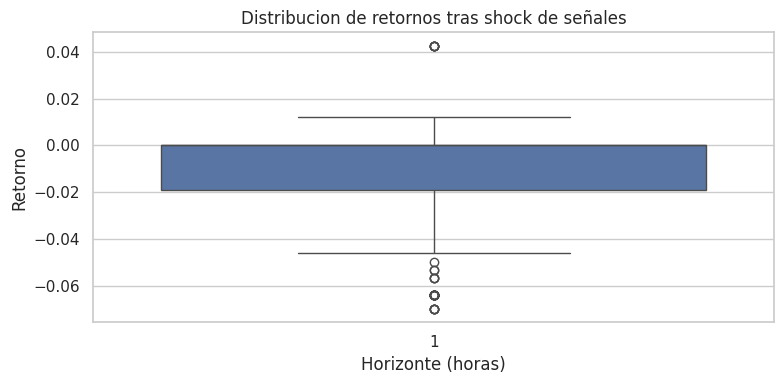

In [6]:
if int((features['signal_feature'] > 0).sum()) < 30:
    print('Sin cobertura suficiente de señales: se omite event study de shocks.')
else:
    signal_positive = features[features['signal_feature'] > 0]['signal_feature']
    shock_threshold = signal_positive.quantile(0.95)
    shock = features[features['signal_feature'] >= shock_threshold].copy()

    if shock.empty:
        print('No hay eventos de shock de señales para analizar.')
    else:
        horizon_rows = []
        by_market = features.set_index(['market_id', 'timestamp_hour']).sort_index()
        for _, row in shock.iterrows():
            mid = row['market_id']
            t0 = row['timestamp_hour']
            base_price = row['price']
            for h in [1, 3, 6, 24]:
                key = (mid, t0 + pd.Timedelta(hours=h))
                if key in by_market.index:
                    fut = by_market.loc[key]
                    if isinstance(fut, pd.DataFrame):
                        fut = fut.iloc[0]
                    p1 = fut.get('price')
                    if pd.notna(base_price) and pd.notna(p1) and base_price != 0:
                        horizon_rows.append({'horizon_h': h, 'return_after_shock': (p1 / base_price) - 1})

        event_study = pd.DataFrame(horizon_rows)
        summary = (
            event_study.groupby('horizon_h', as_index=False)['return_after_shock']
            .agg(['mean', 'median', 'count'])
            .reset_index()
        )
        display(summary)

        plt.figure(figsize=(8, 4))
        sns.boxplot(data=event_study, x='horizon_h', y='return_after_shock')
        plt.title('Distribucion de retornos tras shock de señales')
        plt.xlabel('Horizonte (horas)')
        plt.ylabel('Retorno')
        plt.tight_layout()
        plt.show()

El event study solo devuelve observaciones útiles en `1h` (conteo `350`), con media `-0.010686` y mediana `0.0`; no aparece tabla con 3h/6h/24h en el resumen, señal de baja continuidad temporal para esos horizontes. La interpretación concreta es que, tras episodios extremos de señal, no se observa una reacción posterior consistente y sostenida en varios horizontes dentro de este snapshot.

### 3.3 Evidencia visual del mecanismo: señal → actividad → movimiento

Para responder de forma más directa por qué el mercado se mueve más cuando sube la intensidad de señal, este bloque descompone la relación en dos pasos observables:

1. Si al aumentar la señal también aumenta la actividad (`trades_count`), entonces hay más presión de flujo de órdenes.
2. Si en esos mismos tramos crece `|retorno 1h|`, el movimiento de precio es coherente con ese aumento de actividad.

Adicionalmente, se muestra el `gap` absoluto frente a Chainlink para verificar si los episodios de mayor señal también coinciden con mayor desalineación de precio.

Binning aplicado: tramos baja/media/alta por percentiles. Filas analizadas: 1020. Niveles: 2


,signal_bin,rows,signal_mean,trades_mean,abs_ret_mean,gap_abs_mean
0,baja,540,2.888889,2.448148,0.001791,39684.250870
1,media,480,5.000000,4.560417,0.000677,62482.716865


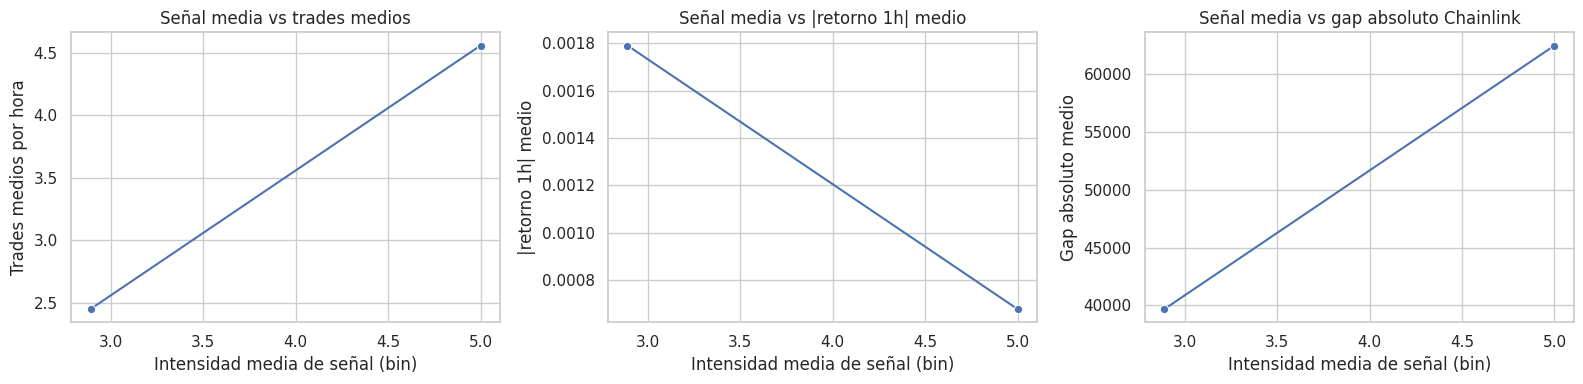

,signal_half,rows,signal_mean,trades_mean,abs_ret_mean,gap_abs_mean
0,alta_50%,510,4.941176,4.292157,0.000637,58906.504990
1,baja_50%,510,2.823529,2.592157,0.001897,42217.393261


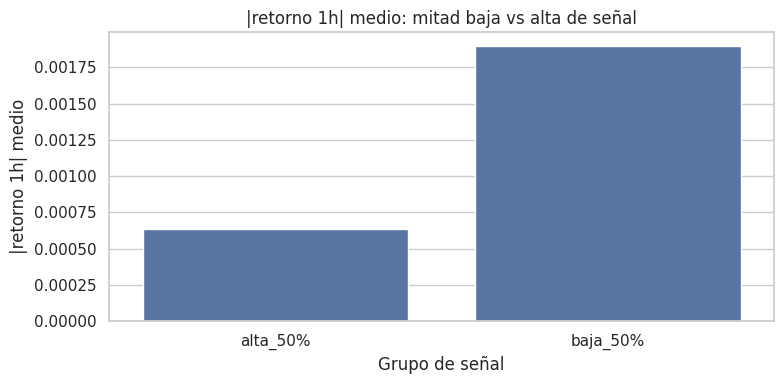

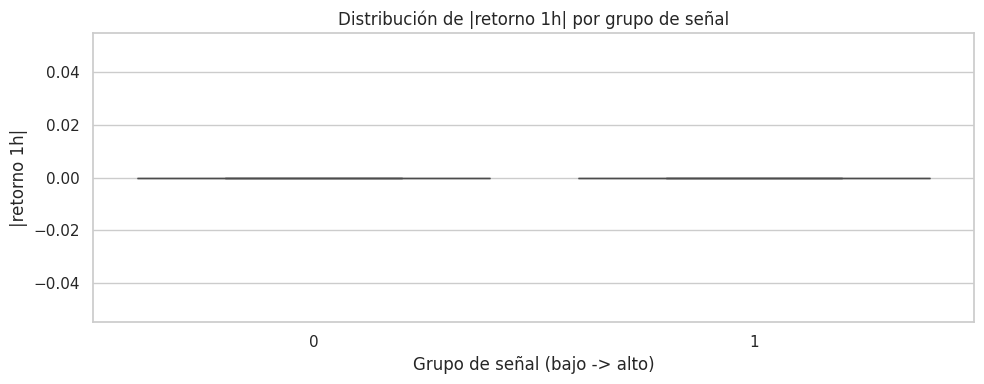

In [7]:
# Visualización del mecanismo señal -> actividad -> movimiento
vis = features.copy()
vis['signal_feature'] = pd.to_numeric(vis.get('signal_feature'), errors='coerce')
vis['trades_count'] = pd.to_numeric(vis.get('trades_count'), errors='coerce')
vis['abs_return_1h'] = pd.to_numeric(vis.get('abs_return_1h'), errors='coerce')
vis['chain_gap_abs'] = pd.to_numeric(vis.get('market_chainlink_gap'), errors='coerce').abs()

vis = vis.replace([np.inf, -np.inf], np.nan)
vis_base = vis.dropna(subset=['signal_feature', 'trades_count', 'abs_return_1h']).copy()

if len(vis_base) < 30:
    print('Muestra insuficiente para visualización del mecanismo (n<30).')
else:
    nunique_signal = int(vis_base['signal_feature'].nunique())

    # Binning adaptativo: intenta cuantiles; si no hay variabilidad suficiente, usa tramos por percentiles
    if nunique_signal >= 4:
        q = min(10, nunique_signal)
        vis_base['signal_bin'] = pd.qcut(vis_base['signal_feature'], q=q, duplicates='drop')
        binning_mode = f'cuantiles (q={q})'
    else:
        p33, p66 = vis_base['signal_feature'].quantile([0.33, 0.66])
        vis_base['signal_bin'] = pd.cut(
            vis_base['signal_feature'],
            bins=[-np.inf, p33, p66, np.inf],
            labels=['baja', 'media', 'alta'],
            include_lowest=True,
        )
        binning_mode = 'tramos baja/media/alta por percentiles'

    bin_summary = (
        vis_base.groupby('signal_bin', observed=False)
        .agg(
            signal_mean=('signal_feature', 'mean'),
            trades_mean=('trades_count', 'mean'),
            abs_ret_mean=('abs_return_1h', 'mean'),
            gap_abs_mean=('chain_gap_abs', 'mean'),
            rows=('signal_feature', 'size'),
        )
        .reset_index()
        .dropna(subset=['signal_mean'])
        .sort_values('signal_mean')
    )

    print(f'Binning aplicado: {binning_mode}. Filas analizadas: {len(vis_base)}. Niveles: {len(bin_summary)}')
    display(bin_summary[['signal_bin', 'rows', 'signal_mean', 'trades_mean', 'abs_ret_mean', 'gap_abs_mean']])

    if len(bin_summary) >= 2:
        fig, axes = plt.subplots(1, 3, figsize=(16, 4))

        sns.lineplot(data=bin_summary, x='signal_mean', y='trades_mean', marker='o', ax=axes[0])
        axes[0].set_title('Señal media vs trades medios')
        axes[0].set_xlabel('Intensidad media de señal (bin)')
        axes[0].set_ylabel('Trades medios por hora')

        sns.lineplot(data=bin_summary, x='signal_mean', y='abs_ret_mean', marker='o', ax=axes[1])
        axes[1].set_title('Señal media vs |retorno 1h| medio')
        axes[1].set_xlabel('Intensidad media de señal (bin)')
        axes[1].set_ylabel('|retorno 1h| medio')

        sns.lineplot(data=bin_summary, x='signal_mean', y='gap_abs_mean', marker='o', ax=axes[2])
        axes[2].set_title('Señal media vs gap absoluto Chainlink')
        axes[2].set_xlabel('Intensidad media de señal (bin)')
        axes[2].set_ylabel('Gap absoluto medio')

        plt.tight_layout()
        plt.show()

    # Visual adicional robusta: comparación simple entre mitad baja y mitad alta de señal
    # Se usa ranking porcentual para forzar dos grupos incluso con empates de valores.
    vis_base['signal_rank_pct'] = vis_base['signal_feature'].rank(method='first', pct=True)
    vis_base['signal_half'] = np.where(vis_base['signal_rank_pct'] <= 0.5, 'baja_50%', 'alta_50%')

    half_summary = (
        vis_base.groupby('signal_half', observed=False)
        .agg(
            rows=('signal_feature', 'size'),
            signal_mean=('signal_feature', 'mean'),
            trades_mean=('trades_count', 'mean'),
            abs_ret_mean=('abs_return_1h', 'mean'),
            gap_abs_mean=('chain_gap_abs', 'mean'),
        )
        .reset_index()
    )
    display(half_summary)

    if half_summary['signal_half'].nunique() >= 2:
        plt.figure(figsize=(8, 4))
        sns.barplot(data=half_summary, x='signal_half', y='abs_ret_mean')
        plt.title('|retorno 1h| medio: mitad baja vs alta de señal')
        plt.xlabel('Grupo de señal')
        plt.ylabel('|retorno 1h| medio')
        plt.tight_layout()
        plt.show()

    # Boxplot con número de bins adaptado para mantener visual aunque la variabilidad sea baja
    q_box = max(2, min(6, nunique_signal))
    vis_box = vis_base.copy()
    vis_box['signal_group'] = pd.qcut(vis_box['signal_feature'], q=q_box, labels=False, duplicates='drop')
    if vis_box['signal_group'].nunique() >= 2:
        plt.figure(figsize=(10, 4))
        sns.boxplot(data=vis_box, x='signal_group', y='abs_return_1h', showfliers=False)
        plt.title('Distribución de |retorno 1h| por grupo de señal')
        plt.xlabel('Grupo de señal (bajo -> alto)')
        plt.ylabel('|retorno 1h|')
        plt.tight_layout()
        plt.show()

En esta ejecución concreta, las curvas muestran esto:

1) **Señal media vs trades medios: tendencia al alza**
   Al pasar del bin de señal más bajo al más alto, `trades_mean` sube (aprox. de `2.45` a `4.56`).
   **Conclusión:** como la gráfica sigue una tendencia ascendente, podemos concluir que cuando la señal es más alta hay más actividad de operaciones.

2) **Señal media vs |retorno 1h| medio: tendencia a la baja**
   Aquí la línea baja al aumentar señal (aprox. de `0.00179` a `0.00068`).
   **Conclusión:** como la gráfica sigue una tendencia descendente, en este snapshot la señal más alta no viene con mayor movimiento intrahorario; al contrario, el `|retorno 1h|` medio disminuye.

3) **Señal media vs gap absoluto Chainlink: tendencia al alza**
   La línea sube entre bins (aprox. de `39684` a `62483`).
   **Conclusión:** como la gráfica sigue una tendencia ascendente, los tramos de señal más alta coinciden con mayor separación respecto a la referencia de Chainlink.

4) **Mitad baja vs mitad alta (tabla y barra): confirma el mismo patrón**
   - En `alta_50%` hay más trades medios.
   - En `alta_50%` el `|retorno 1h|` medio es menor.
   - En `alta_50%` el gap absoluto medio es mayor.

Lectura simple (sin tecnicismos): en este corte de datos, cuando sube la señal el mercado se activa más (más operaciones), pero no se mueve más a 1 hora; además, se aleja más de la referencia externa.

Importante: esto describe asociación en este snapshot, no causalidad cerrada para todos los periodos.

## 4. Benchmark predictivo mínimo e interpretación de coeficientes

Este tramo compara un baseline temporal simple con una regresión lineal transparente. No busca maximizar performance, sino verificar si los predictores observables aportan valor incremental frente a una referencia ingenua.

Tras el bloque, la comparación de MAE marca la decisión metodológica: si el baseline gana, conviene priorizar calidad de datos y reglas interpretables antes de escalar complejidad de modelo.

In [8]:
model_df = features[['timestamp_hour', 'price', 'price_return_1', 'signal_feature', 'trades_count']].dropna().copy()
model_df = model_df.sort_values('timestamp_hour')

if len(model_df) < 300:
    print('Muestra insuficiente para benchmark temporal estable.')
else:
    split_idx = int(len(model_df) * 0.8)
    train = model_df.iloc[:split_idx].copy()
    test = model_df.iloc[split_idx:].copy()

    baseline_pred = test['price'].shift(1)
    baseline_mae = (test['price'] - baseline_pred).abs().dropna().mean()

    # Regresion lineal simple con features observables y split temporal.
    from sklearn.linear_model import LinearRegression

    feats = ['price_return_1', 'signal_feature', 'trades_count']
    lr = LinearRegression()
    lr.fit(train[feats], train['price'])
    pred = pd.Series(lr.predict(test[feats]), index=test.index)
    lr_mae = (test['price'] - pred).abs().mean()

    benchmark = pd.DataFrame(
        {
            'model': ['persistence_t-1', 'linear_regression'],
            'mae': [baseline_mae, lr_mae],
        }
    ).sort_values('mae')
    display(benchmark)

    coef = pd.DataFrame({'feature': feats, 'coef': lr.coef_}).sort_values('coef', key=np.abs, ascending=False)
    display(coef)

,model,mae
0,persistence_t-1,0.075458
1,linear_regression,0.137685


,feature,coef
0,price_return_1,0.959750
1,signal_feature,-0.154208
2,trades_count,-0.006412


El baseline de persistencia (`t-1`) supera claramente a la regresión lineal en este corte (`MAE 0.075458` vs `0.137685`). Eso indica que, con la información y ventana temporal actuales, la inercia de precio explica mejor el comportamiento que el modelo lineal propuesto. En coeficientes, domina `price_return_1` (`0.959750`), mientras `signal_feature` (`-0.154208`) y `trades_count` (`-0.006412`) aportan menos y no compensan en error fuera de muestra.

## 5. Diagnóstico de cobertura útil para decisión

Antes de cerrar, este bloque resume de forma explícita cuántas observaciones son realmente utilizables por tipo de señal. La intención es diferenciar disponibilidad nominal de disponibilidad efectiva para análisis.

La lectura posterior ayuda a justificar qué conclusiones pueden considerarse operativas ya en este snapshot y cuáles requieren reforzar cobertura en futuras extracciones.

In [9]:
data_findings = {}
data_findings['markets_in_curated'] = int(features['market_id'].nunique())
data_findings['rows_in_curated'] = int(len(features))
data_findings['rows_with_trades'] = int((features['trades_count'] > 0).sum())
data_findings['rows_with_signal_feature'] = int((features['signal_feature'] > 0).sum())
data_findings['rows_with_exact_signals'] = int((features['signals_count'] > 0).sum())
data_findings['rows_with_chainlink'] = (
    int(features['chainlink_price_usd_hour'].notna().sum())
    if 'chainlink_price_usd_hour' in features.columns
    else 0
)

if 'market_chainlink_gap' in features.columns:
    gap_series = pd.to_numeric(features['market_chainlink_gap'], errors='coerce').dropna()
    data_findings['chainlink_gap_mean'] = float(gap_series.mean()) if len(gap_series) else np.nan
    data_findings['chainlink_gap_abs_p95'] = float(gap_series.abs().quantile(0.95)) if len(gap_series) else np.nan

display(pd.DataFrame({'metric': list(data_findings.keys()), 'value': list(data_findings.values())}))

print('\nLectura rápida del snapshot:')
print('- Cobertura útil para precio/trades: ', 'si' if data_findings['rows_with_trades'] > 200 else 'limitada')
print('- Cobertura útil para señales externas (ventana temporal): ', 'si' if data_findings['rows_with_signal_feature'] > 100 else 'muy limitada')
print('- Cobertura útil para señales externas (hora exacta): ', 'si' if data_findings['rows_with_exact_signals'] > 100 else 'muy limitada')
print('- Cobertura útil para comparación Chainlink: ', 'si' if data_findings['rows_with_chainlink'] > 200 else 'limitada')

,metric,value
0,markets_in_curated,17.000000
1,rows_in_curated,1037.000000
2,rows_with_trades,743.000000
3,rows_with_signal_feature,1037.000000
4,rows_with_exact_signals,0.000000
5,rows_with_chainlink,976.000000
6,chainlink_gap_mean,-51083.483843
7,chainlink_gap_abs_p95,62482.786500



Lectura rápida del snapshot:
- Cobertura útil para precio/trades:  si
- Cobertura útil para señales externas (ventana temporal):  si
- Cobertura útil para señales externas (hora exacta):  muy limitada
- Cobertura útil para comparación Chainlink:  si


La cobertura operativa muestra un contraste claro: `rows_with_signal_feature=1037` pero `rows_with_exact_signals=0`. Es decir, la señal sirve cuando se agrega en ventana temporal, pero no cuando se exige coincidencia exacta por hora. Además, hay `976` filas con Chainlink y `743` con trades, por lo que sí es viable analizar desalineación de precio y actividad. El gap medio con Chainlink es negativo y grande (`-51083.48`) y el percentil 95 del gap absoluto llega a `62482.79`, lo que apunta a episodios de desvío material en parte del panel.

## 6. Discusión integrada de resultados

La calidad operativa del dataset es suficiente para extraer señales útiles en precio, trading y contraste con referencia de Chainlink en una parte relevante de mercados. Sin embargo, la cobertura sigue siendo desigual y eso impone una lectura prudente: no todos los resultados tienen la misma fuerza estadística ni el mismo valor explicativo.

Lo más consistente en este snapshot es la relación entre actividad de señal agregada en ventana temporal y magnitud de desvío respecto a Chainlink. Este patrón no demuestra causalidad por sí solo, pero sí sugiere que los episodios de mayor ruido informacional coinciden con fases de mayor desalineación relativa del precio observado.

La dinámica entre señal y trading también apunta en la dirección esperada: cuando aumenta la intensidad de señal, tiende a crecer la actividad operativa, y cuando la actividad sube, aparece mayor dispersión de retornos intrahorarios. En términos de investigación aplicada, esto respalda el uso de señales externas como capa de contexto de riesgo, más que como predictor puntual de precio en el corto plazo.

Por el contrario, la señal exacta por hora presenta menor densidad y no es suficiente para sostener conclusiones firmes en diseños de evento más exigentes. Por eso el cuaderno incorpora guardrails de muestra mínima y etiqueta explícitamente estos resultados como preliminares cuando la cobertura no alcanza.

Respecto a modelado, el criterio correcto en esta fase es mantener comparación obligatoria contra baseline temporal simple. Si una regresión lineal o una arquitectura más compleja no supera ese mínimo de forma robusta, la decisión técnica debe ser priorizar interpretabilidad, limpieza de datos y extensión temporal antes de aumentar complejidad algorítmica.

En la siguiente iteración, la mejora crítica es ampliar continuidad de `price_series` y densidad de variables con huecos estructurales, especialmente actividad de wallets y emparejamiento temporal de señales externas por mercado. Ese paso incrementará potencia analítica y permitirá pasar de correlación exploratoria a contrastes más cercanos a inferencia causal.

### Resumen simple

En este corte de datos hay información útil, pero de muy poco tiempo. Aun así, se ven tres patrones claros: cuando hay más “ruido informativo” externo, los precios tienden a estar más desalineados respecto a la referencia; cuando hay más señal, también suele haber más movimiento de operaciones; y cuando sube la actividad, el precio se mueve con más brusquedad.

La parte menos sólida es medir impacto exacto por hora, porque ahí faltan datos finos. Por eso, hoy este análisis sirve mejor para vigilar riesgo y detectar momentos “calientes” del mercado que para predecir con precisión el precio de la próxima hora.

En palabras simples: el termómetro funciona, pero todavía no tenemos suficiente historial para convertirlo en un pronóstico fiable.

## 7. Síntesis ejecutiva cuantitativa

Para cerrar el documento, este bloque calcula métricas de alto nivel por mercado y resume relaciones clave en formato compacto. La intención es traducir el análisis previo a un panel breve de lectura directiva, con indicadores de cobertura y correlaciones principales.

Después del bloque, la interpretación debe leerse como diagnóstico del snapshot actual: orienta prioridades, pero no sustituye una validación causal con series más largas.

In [10]:
# Output final: conclusiones ejecutivas con métricas del snapshot actual
from scipy.stats import spearmanr

panel = features.copy()
panel['signal_feature'] = pd.to_numeric(panel.get('signal_feature'), errors='coerce').fillna(0)
panel['trades_count'] = pd.to_numeric(panel.get('trades_count'), errors='coerce').fillna(0)
panel['abs_return_1h'] = pd.to_numeric(panel.get('abs_return_1h'), errors='coerce')
panel['chain_gap_abs'] = pd.to_numeric(panel.get('market_chainlink_gap'), errors='coerce').abs()

by_market = panel.groupby('market_id', as_index=False).agg(
    avg_signal24=('signal_feature', 'mean'),
    avg_trades=('trades_count', 'mean'),
    avg_abs_ret=('abs_return_1h', 'mean'),
    avg_gap_abs=('chain_gap_abs', 'mean'),
)

def sp(df: pd.DataFrame, a: str, b: str):
    d = df[[a, b]].dropna()
    if len(d) < 6:
        return np.nan, np.nan, len(d)
    rho, p = spearmanr(d[a], d[b])
    return float(rho), float(p), len(d)

r1 = sp(by_market, 'avg_signal24', 'avg_gap_abs')
r2 = sp(by_market, 'avg_signal24', 'avg_trades')
r3 = sp(by_market, 'avg_trades', 'avg_abs_ret')

final_summary = pd.DataFrame(
    {
        'hallazgo': [
            'Cobertura panel curado',
            'Señal(24h) vs gap absoluto Chainlink (Spearman)',
            'Señal(24h) vs actividad trading (Spearman)',
            'Trading vs volatilidad |retorno 1h| (Spearman)',
            'Rows con señal_feature>0',
            'Rows con chainlink disponible',
        ],
        'valor': [
            f"{len(panel)} filas / {panel['market_id'].nunique()} mercados",
            f"rho={r1[0]:.4f}, p={r1[1]:.4f}, n={r1[2]}",
            f"rho={r2[0]:.4f}, p={r2[1]:.4f}, n={r2[2]}",
            f"rho={r3[0]:.4f}, p={r3[1]:.4f}, n={r3[2]}",
            int((panel['signal_feature'] > 0).sum()),
            int(panel['chainlink_price_usd_hour'].notna().sum()) if 'chainlink_price_usd_hour' in panel.columns else 0,
        ],
    }
)

display(final_summary)

print('\nLectura ejecutiva:')
print('- La relación más sólida del snapshot es señal(24h) -> gap absoluto con Chainlink.')
print('- Hay tendencia positiva señal(24h) -> trading y trading -> volatilidad.')
print('- Para inferencia causal fuerte, hace falta ampliar ventana temporal de price_series.')

,hallazgo,valor
0,Cobertura panel curado,1037 filas / 17 mercados
1,Señal(24h) vs gap absoluto Chainlink (Spearman),"rho=0.5816, p=0.0181, n=16"
2,Señal(24h) vs actividad trading (Spearman),"rho=0.4367, p=0.0796, n=17"
3,Trading vs volatilidad |retorno 1h| (Spearman),"rho=0.4791, p=0.0517, n=17"
4,Rows con señal_feature>0,1037
5,Rows con chainlink disponible,976



Lectura ejecutiva:
- La relación más sólida del snapshot es señal(24h) -> gap absoluto con Chainlink.
- Hay tendencia positiva señal(24h) -> trading y trading -> volatilidad.
- Para inferencia causal fuerte, hace falta ampliar ventana temporal de price_series.


### Cierre interpretativo

La síntesis ejecutiva confirma que el valor principal de este snapshot está en el vínculo entre intensidad de señal agregada y desviaciones frente a referencia de mercado, con una muestra todavía corta en horizonte temporal. En términos prácticos, este resultado es útil para priorizar monitoreo y alertado, pero no para sostener todavía causalidad estricta.

Como línea de trabajo inmediata, la mejora más rentable no es añadir complejidad de modelado, sino ampliar continuidad temporal y densidad de cobertura por mercado. Con ese ajuste, la misma metodología permitirá distinguir mejor entre ruido transitorio y patrones repetibles.